# Model Comparison - Airline Passenger Satisfaction

This notebook compares the four trained models on the validation set using the saved metrics from `reports/`.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

In [2]:
# Load metrics from reports folder
reports_dir = Path("../reports")
metric_files = [
    "baseline_metrics.json",
    "decision_tree_metrics.json",
    "random_forest_metrics.json",
    "gradient_boosting_metrics.json"
]

models_data = []
for fname in metric_files:
    with open(reports_dir / fname) as f:
        data = json.load(f)
    models_data.append(data)

print(f"Loaded {len(models_data)} model metrics")

Loaded 4 model metrics


In [3]:
# Create comparison DataFrame
comparison_rows = []
for m in models_data:
    metrics = m["metrics"]
    comparison_rows.append({
        "Model": m["model"],
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1-Score": metrics["f1"],
        "ROC-AUC": metrics["roc_auc"]
    })

df = pd.DataFrame(comparison_rows)
df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8690,0.8396,0.8625,0.8509,0.9281
1,Decision Tree,0.9243,0.9027,0.9250,0.9137,0.9738
2,Random Forest,0.9567,0.9501,0.9499,0.9500,0.9932
3,Gradient Boosting,0.9601,0.9662,0.9408,0.9534,0.9940


In [4]:
# Display accuracy as percentage
print("Accuracy as Percentage:")
for _, row in df.iterrows():
    print(f"{row['Model']}: {row['Accuracy'] * 100:.2f}%")

Accuracy as Percentage:
Logistic Regression: 86.90%
Decision Tree: 92.43%
Random Forest: 95.67%
Gradient Boosting: 96.01%


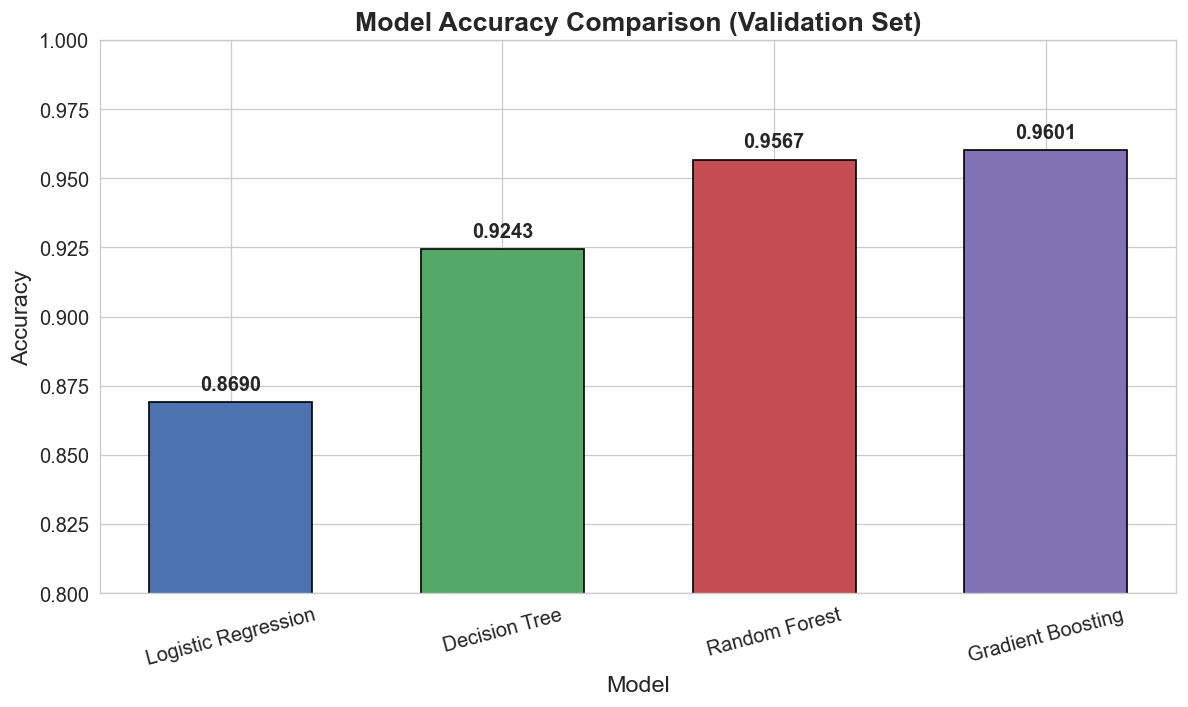

In [5]:
# Bar chart comparing accuracy
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b3"]
bars = ax.bar(df["Model"], df["Accuracy"], color=colors, edgecolor="black", width=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Model Accuracy Comparison (Validation Set)", fontsize=16, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=14)
ax.set_xlabel("Model", fontsize=14)
ax.set_ylim(0.8, 1.0)
ax.tick_params(axis="x", rotation=15, labelsize=12)
ax.tick_params(axis="y", labelsize=12)
plt.tight_layout()
plt.show()

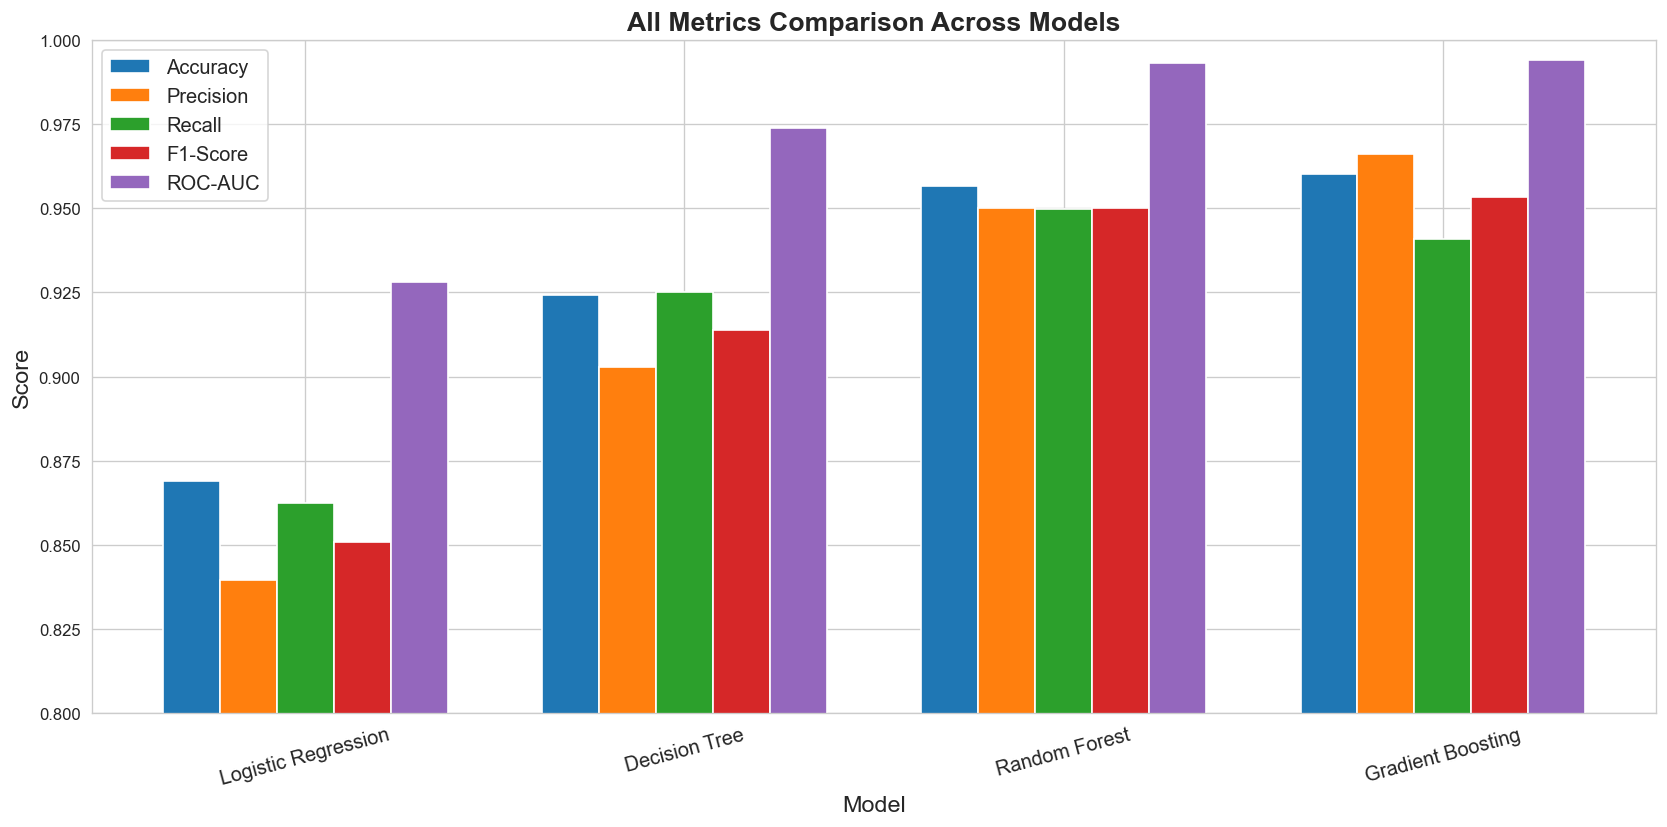

In [6]:
# Additional comparison chart - all metrics
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x = range(len(df["Model"]))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))
for i, metric in enumerate(metrics_to_plot):
    ax.bar([xi + i * width for xi in x], df[metric], width, label=metric)

ax.set_xlabel("Model", fontsize=14)
ax.set_ylabel("Score", fontsize=14)
ax.set_title("All Metrics Comparison Across Models", fontsize=16, fontweight="bold")
ax.set_xticks([xi + 2 * width for xi in x])
ax.set_xticklabels(df["Model"], rotation=15, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

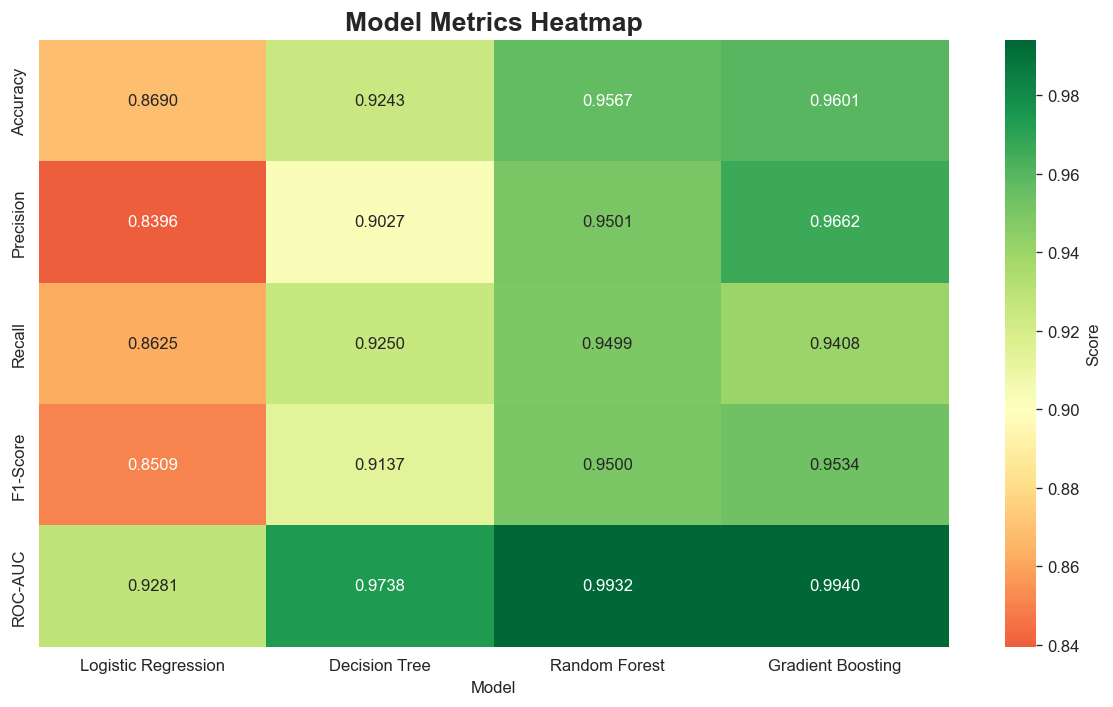

In [7]:
# Heatmap of all metrics
heatmap_data = df.set_index("Model")[metrics_to_plot].T
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="RdYlGn", center=0.9, ax=ax, cbar_kws={"label": "Score"})
ax.set_title("Model Metrics Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

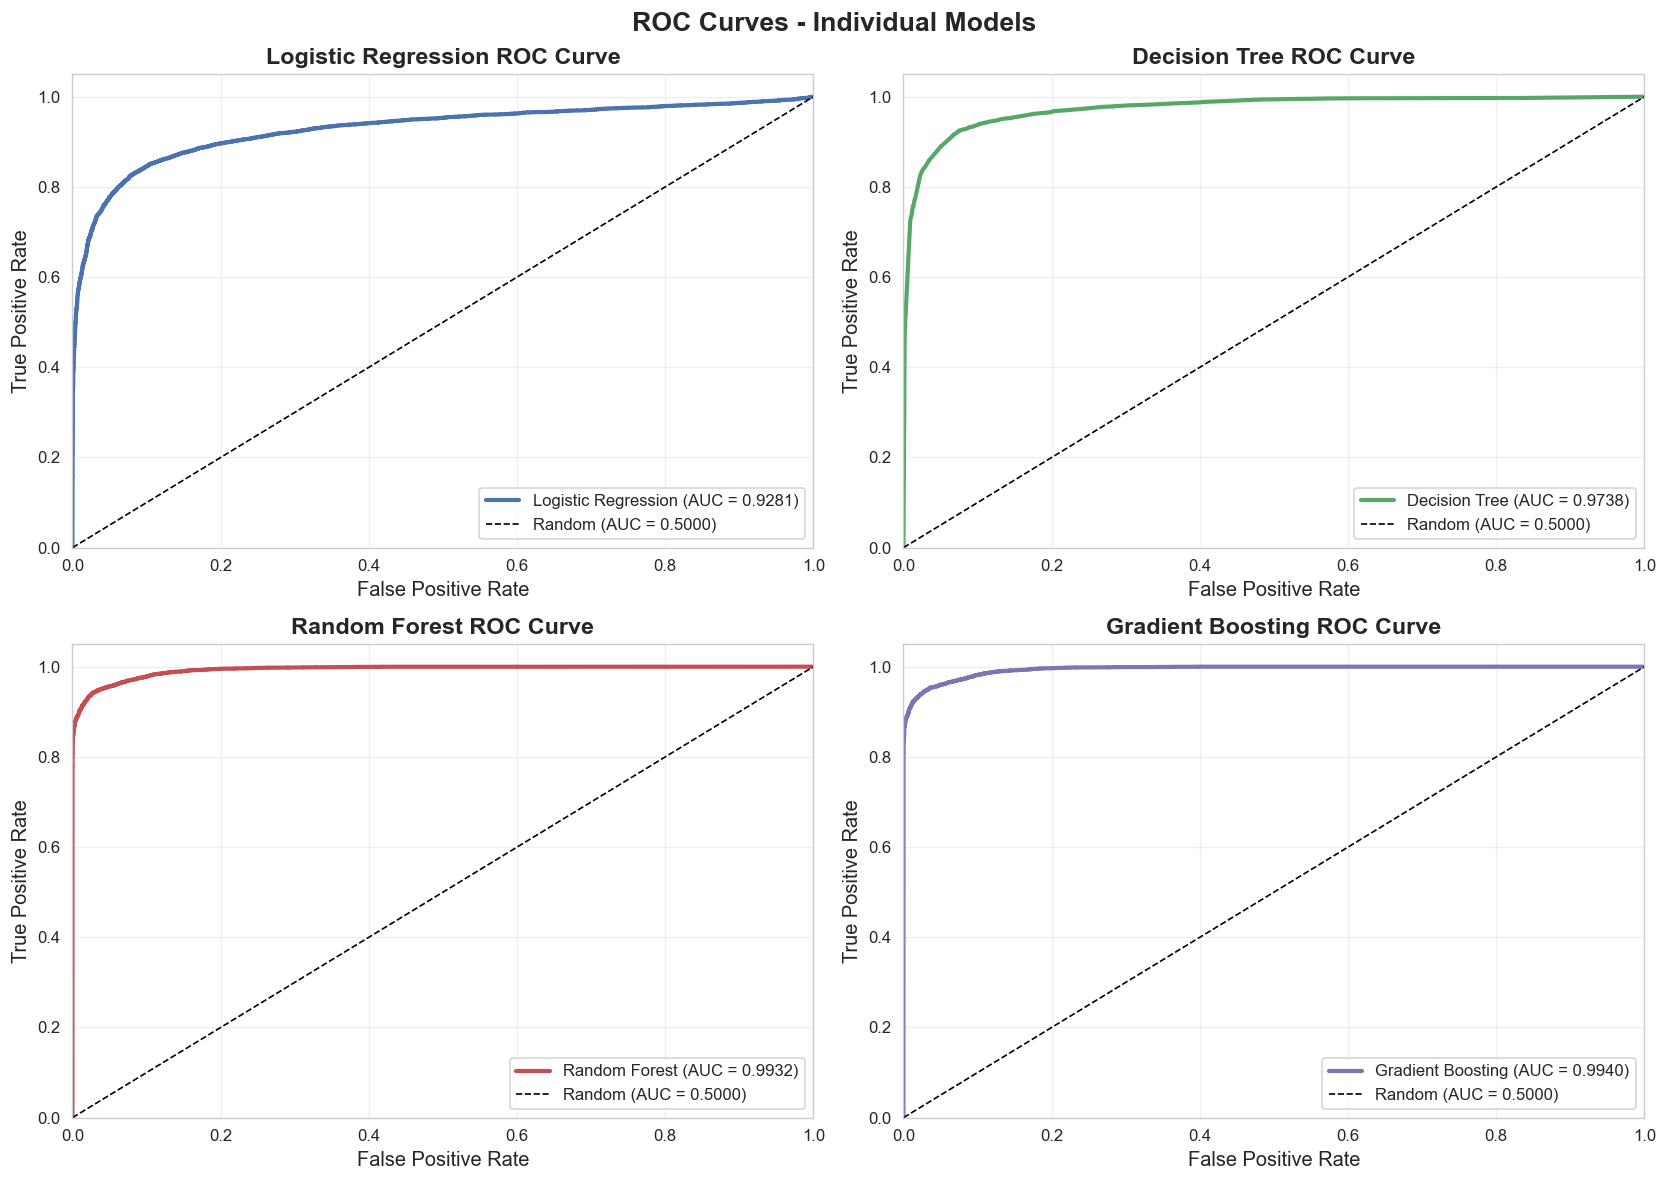

In [8]:
# Individual ROC Curves for Each Model
import joblib
from sklearn.metrics import roc_curve, auc
import pandas as pd
import numpy as np
from pathlib import Path

# Load and preprocess data inline (no src import needed)
train_path = Path('../dataset/train.csv')
train_raw = pd.read_csv(train_path)

# Clean data inline (same as src/preprocessing.py)
ID_COLUMNS = ["Unnamed: 0", "id"]
train_clean = train_raw.copy()
cols_to_drop = [c for c in ID_COLUMNS if c in train_clean.columns]
train_clean = train_clean.drop(columns=cols_to_drop, errors="ignore")
train_clean = train_clean.drop_duplicates().reset_index(drop=True)

# Impute Arrival Delay
if "Arrival Delay in Minutes" in train_clean.columns:
    median_delay = train_clean["Arrival Delay in Minutes"].median()
    train_clean["Arrival Delay in Minutes"] = train_clean["Arrival Delay in Minutes"].fillna(median_delay)

# Encode target
TARGET_MAPPING = {"neutral or dissatisfied": 0, "satisfied": 1}
train_clean["satisfaction"] = train_clean["satisfaction"].map(TARGET_MAPPING).astype("int8")

# Split
X = train_clean.drop(columns=["satisfaction"])
y = train_clean["satisfaction"]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model paths
model_files = {
    'Logistic Regression': '../models/baseline_logistic_regression.joblib',
    'Decision Tree': '../models/decision_tree.joblib',
    'Random Forest': '../models/random_forest.joblib',
    'Gradient Boosting': '../models/gradient_boosting.joblib'
}

# Create individual ROC curve for each model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

for i, (name, path) in enumerate(model_files.items()):
    model = joblib.load(path)
    y_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    
    ax = axes[i]
    ax.plot(fpr, tpr, color=colors[i], lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5000)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{name} ROC Curve', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves - Individual Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Test Evaluation — Gradient Boosting

This section evaluates the Gradient Boosting model on the held-out test set (`dataset/test.csv`), using the pre-trained pipeline from `models/gradient_boosting.joblib`. The model was selected based on validation results (highest accuracy and ROC-AUC). The test set was never used for model selection or hyperparameter tuning.

In [9]:
# Load final test metrics
from pathlib import Path
import json

reports_dir = Path("../reports")
with open(reports_dir / "final_test_metrics.json") as f:
    test_metrics = json.load(f)

print(f"Model: {test_metrics['model']}")
print(f"Evaluation set: {test_metrics['evaluation_set']}")
print(f"Positive class: {test_metrics['positive_class']} ({test_metrics['positive_class_label']})")
print()

m = test_metrics['metrics']
print("Test Metrics:")
print(f"  Accuracy:     {m['accuracy']*100:.2f}%")
print(f"  Precision:    {m['precision']*100:.2f}%")
print(f"  Recall:       {m['recall']*100:.2f}%")
print(f"  F1-Score:     {m['f1']*100:.2f}%")
print(f"  ROC-AUC:      {m['roc_auc']:.4f}")

Model: Gradient Boosting
Evaluation set: test (held-out)
Positive class: 1 (satisfied)

Test Metrics:
  Accuracy:     95.95%
  Precision:    96.77%
  Recall:       93.91%
  F1-Score:     95.32%
  ROC-AUC:      0.9937


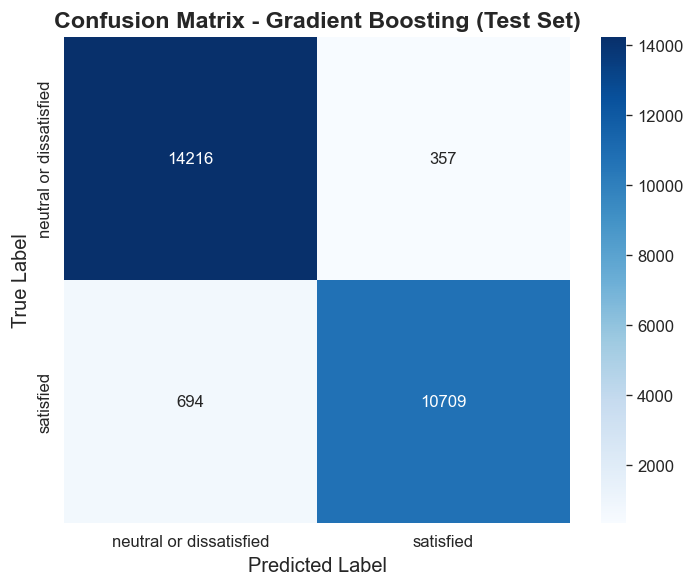

Confusion Matrix (Test Set):
[[14216   357]
 [  694 10709]]


In [10]:
# Test confusion matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm = np.array(test_metrics['metrics']['confusion_matrix'])
labels = ['neutral or dissatisfied', 'satisfied']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Confusion Matrix - Gradient Boosting (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print('Confusion Matrix (Test Set):')
print(cm)

### Saved Evaluation Figures

The following figures were saved during final evaluation and are displayed below.

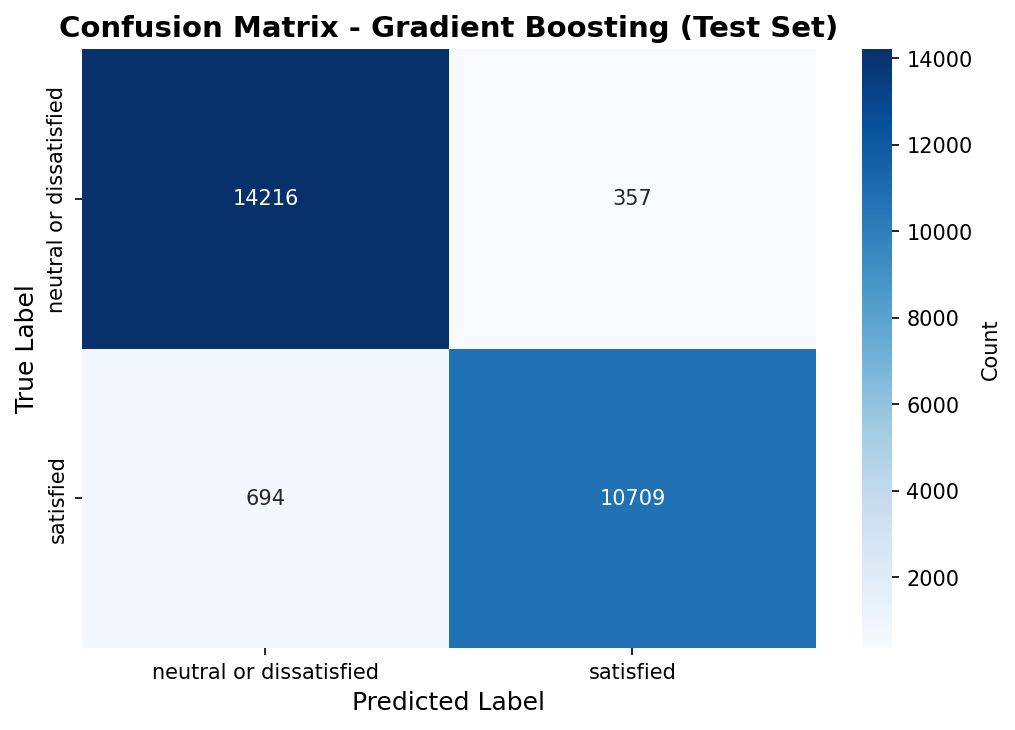

In [11]:
# Display saved confusion matrix figure
from IPython.display import Image, display
from pathlib import Path

figures_dir = Path("../reports/figures")

cm_path = figures_dir / "confusion_matrix_gradient_boosting_test.png"
if cm_path.exists():
    display(Image(filename=str(cm_path)))
else:
    print(f"File not found: {cm_path}")

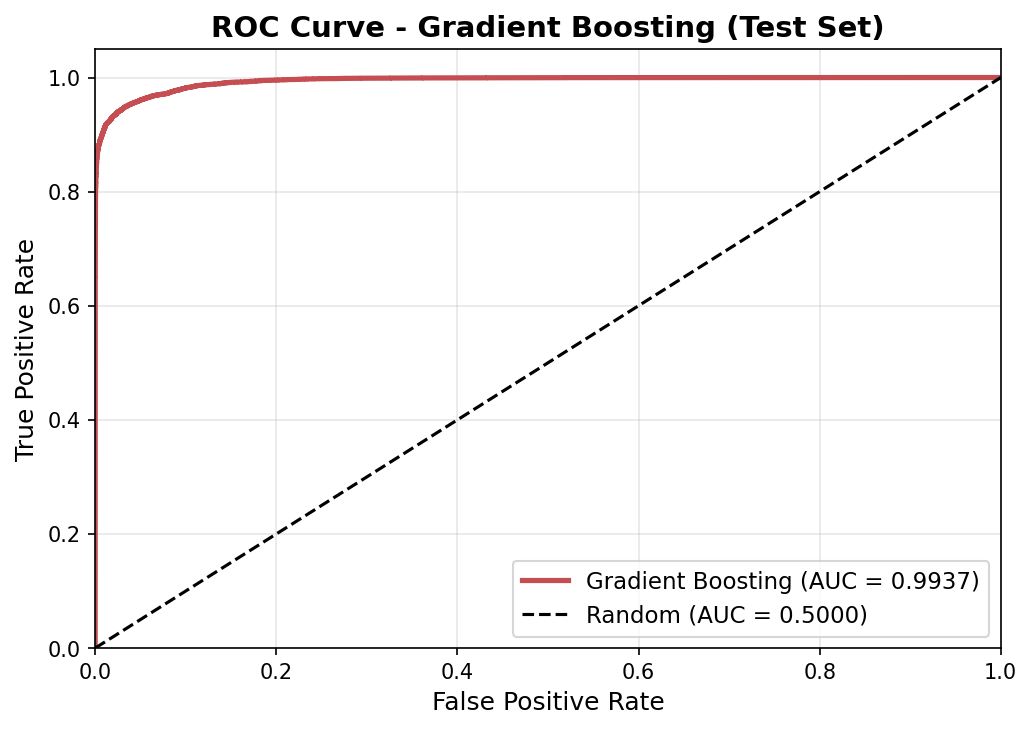

In [12]:
# Display saved ROC curve figure
roc_path = figures_dir / "roc_curve_gradient_boosting_test.png"
if roc_path.exists():
    display(Image(filename=str(roc_path)))
else:
    print(f"File not found: {roc_path}")

In [13]:
# Validation vs Test comparison for Gradient Boosting
import pandas as pd

val_acc = 0.9601
test_acc = test_metrics['metrics']['accuracy']

comparison = pd.DataFrame({
    'Set': ['Validation', 'Test'],
    'Accuracy': [val_acc, test_acc],
    'Precision': [0.9662, test_metrics['metrics']['precision']],
    'Recall': [0.9408, test_metrics['metrics']['recall']],
    'F1-Score': [0.9534, test_metrics['metrics']['f1']],
    'ROC-AUC': [0.9940, test_metrics['metrics']['roc_auc']]
})

print("Gradient Boosting: Validation vs Test")
print(comparison.to_string(index=False))

print(f"\nAccuracy difference: {(test_acc - val_acc)*100:+.2f}%")

Gradient Boosting: Validation vs Test
       Set  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Validation    0.9601     0.9662  0.9408    0.9534   0.9940
      Test    0.9595     0.9677  0.9391    0.9532   0.9937

Accuracy difference: -0.06%


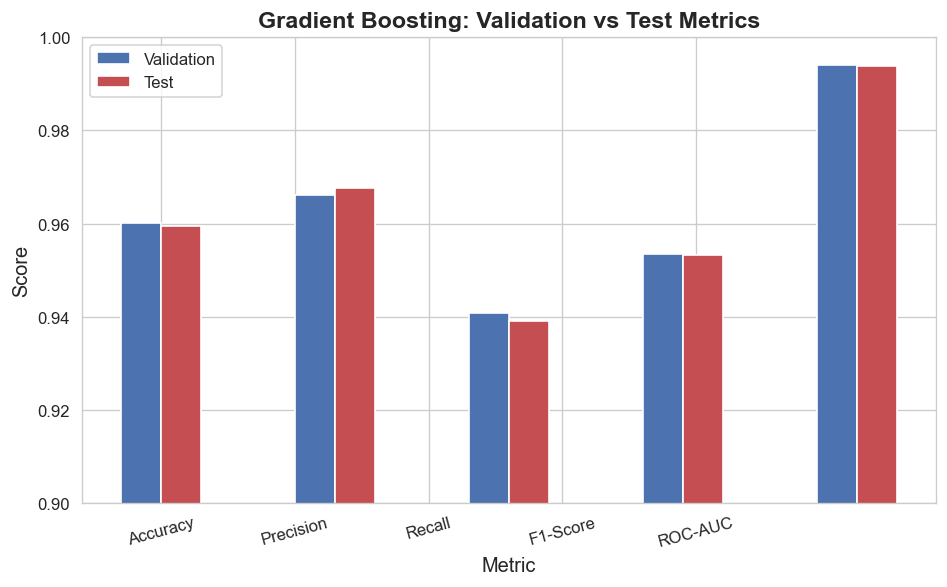

In [14]:
# Validation vs Test bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = ['Validation', 'Test']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
val_scores = [0.9601, 0.9662, 0.9408, 0.9534, 0.9940]
test_scores = [
    test_metrics['metrics']['accuracy'],
    test_metrics['metrics']['precision'],
    test_metrics['metrics']['recall'],
    test_metrics['metrics']['f1'],
    test_metrics['metrics']['roc_auc']
]

x_pos = range(len(metrics_names))
width = 0.3

ax.bar([x + i*width for i, x in enumerate(x_pos)], val_scores, width, label='Validation', color='#4c72b0')
ax.bar([x + (i+1)*width for i, x in enumerate(x_pos)], test_scores, width, label='Test', color='#c44e52')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Gradient Boosting: Validation vs Test Metrics', fontsize=14, fontweight='bold')
ax.set_xticks([x + width/2 for x in x_pos])
ax.set_xticklabels(metrics_names, rotation=15)
ax.legend()
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

## Final Test Evaluation Conclusion

**Gradient Boosting** was selected for final evaluation based on its highest validation accuracy (96.01%) and ROC-AUC (0.9940) among the four models. The model was evaluated on the completely held-out test set (`dataset/test.csv` with 25,976 samples), which was never used during model selection or training.

**Test Results (Gradient Boosting):**
- **Accuracy: 95.95%** (validation: 96.01%)
- **Precision: 96.77%** (validation: 96.62%)
- **Recall: 93.91%** (validation: 94.08%)
- **F1-Score: 95.32%** (validation: 95.34%)
- **ROC-AUC: 0.9937** (validation: 0.9940)

The test accuracy (95.95%) is very close to the validation accuracy (96.01%), with a difference of only -0.06%, indicating excellent generalization and no overfitting.

---

### Important Notes:

1. **Model Selection**: Gradient Boosting was selected using validation results only. The test set was never used for model selection or hyperparameter tuning.

2. **Random Forest Recall Note**: Random Forest achieved slightly higher validation recall (94.99%) compared to Gradient Boosting (94.08%). This trade-off was documented during model selection.

3. **Validation vs Test for Other Models**: The other three models (Logistic Regression, Decision Tree, Random Forest) have **validation results only**. Their validation accuracies (86.90%, 92.43%, 95.67%) **are not test accuracies** and should not be presented as such. Only Gradient Boosting has been evaluated on the held-out test set.

4. **No Data Leakage**: The test set was completely untouched until this final evaluation. All preprocessing (imputation, encoding, scaling) was fit on the training split only.

5. **Generalization**: The test accuracy (95.95%) is nearly identical to validation accuracy (96.01%), confirming excellent generalization with no overfitting.

## Conclusion

**Gradient Boosting** achieves the highest validation accuracy at **96.01%**, followed by Random Forest (95.67%), Decision Tree (92.43%), and Logistic Regression (86.90%).

Gradient Boosting also achieves the highest Precision (96.62%), F1-Score (95.34%), and ROC-AUC (99.40%), making it the best performing model on the validation set. However, it has slightly lower Recall (94.08%) compared to Random Forest (94.99%).

**Recommendation**: Gradient Boosting is the best performing model on the validation set and should be considered for the final model. The test set evaluation should be performed on the held-out test data to confirm generalization before deployment.